<a href="https://colab.research.google.com/github/aryan30-tp/Deep-learning/blob/main/FaceCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [11]:
import os

# Point to the actual subdirectory if needed (unrar often creates a subfolder)
# Based on your previous output, it seems to be in /content/dataset/Fifa_player_dataset
data_path = '/content/dataset/Fifa_player_dataset'

# Create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

# Create testing (validation) dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=32
)

print("Datasets created successfully.")

Found 872 files belonging to 3 classes.
Using 698 files for training.
Found 872 files belonging to 3 classes.
Using 174 files for validation.
Datasets created successfully.


In [4]:
!pip install unrar
!mkdir -p /content/dataset
!unrar x "/content/Football players faces dataset.rar" /content/dataset/


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Football players faces dataset.rar


Would you like to replace the existing file /content/dataset/Fifa_player_dataset/Courtois/chrome_076AA3hINd.png
 87767 bytes, modified on 2021-12-03 21:51
with a new one
 87767 bytes, modified on 2021-12-03 21:51

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit 
User break

User break


In [12]:
import numpy as np

# Convert the training dataset to numpy arrays
X_train = []
y_train = []
for images, labels in train_ds:
    X_train.append(images.numpy())
    y_train.append(labels.numpy())

X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

# Convert the testing (validation) dataset to numpy arrays
X_test = []
y_test = []
for images, labels in test_ds:
    X_test.append(images.numpy())
    y_test.append(labels.numpy())

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (698, 128, 128, 3)
y_train shape: (698,)
X_test shape: (174, 128, 128, 3)
y_test shape: (174,)


In [105]:
# Updated to match the 3 classes found in the directory
labels = ["Courtois", "Dybala", "Kroos"]

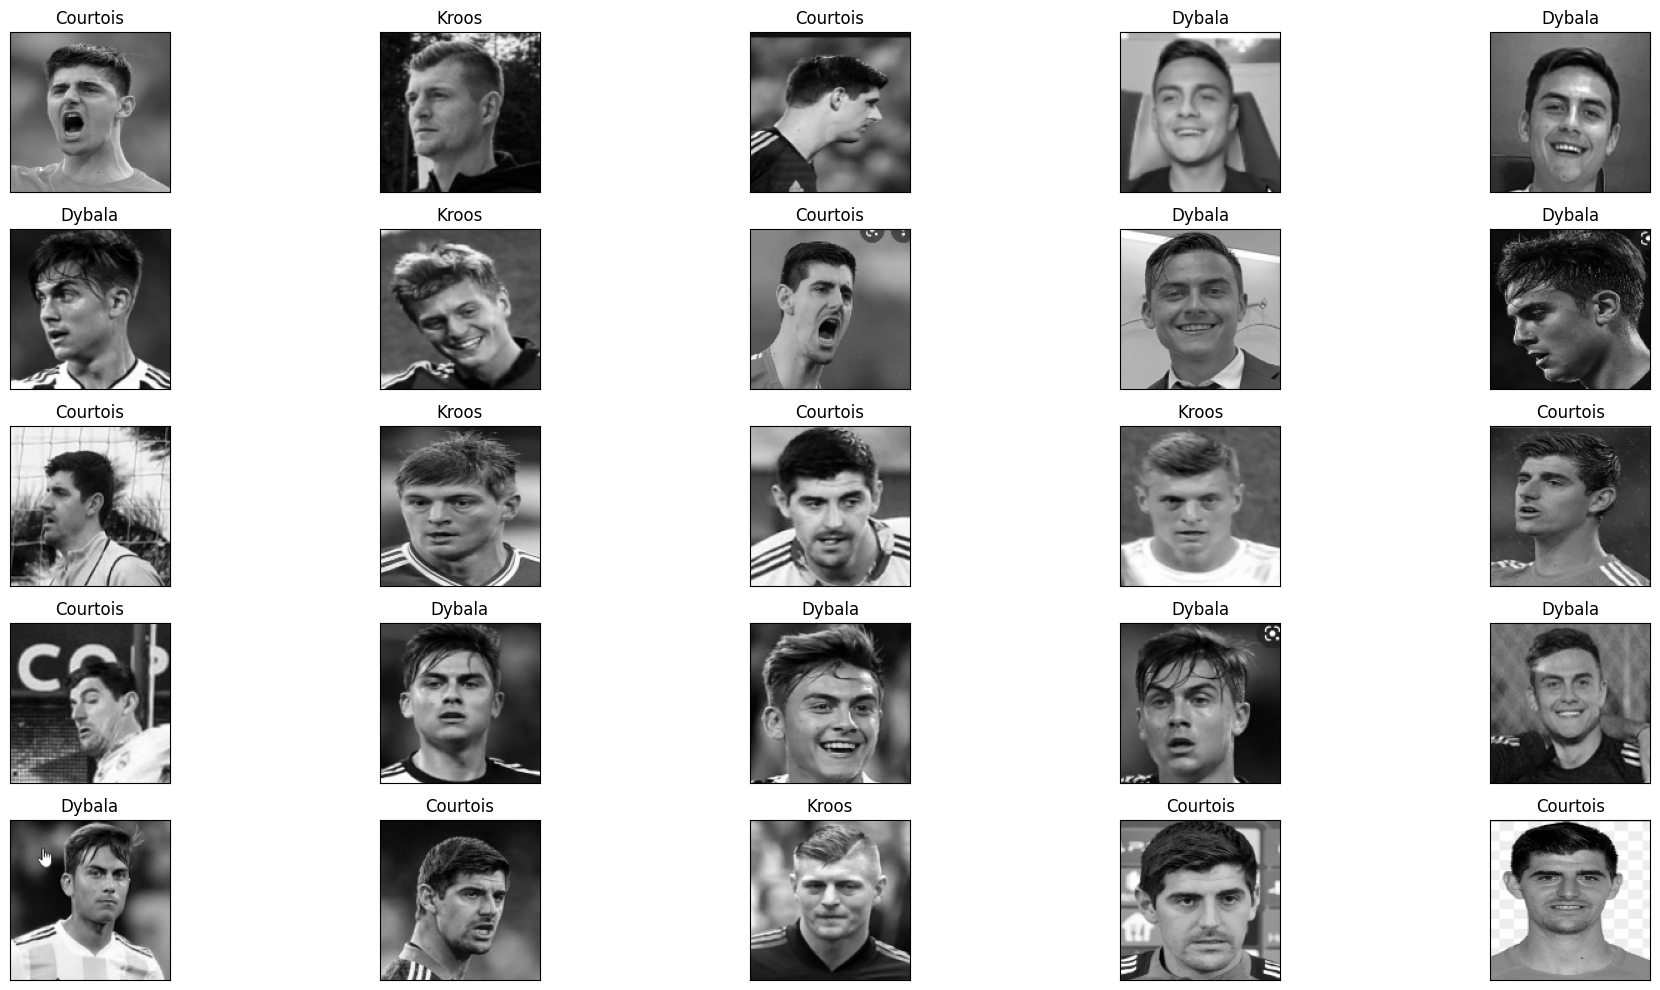

New X_train shape: (698, 128, 128)


In [15]:
# Convert datasets to Black & White (Grayscale) by averaging the RGB channels
X_train = np.mean(X_train, axis=-1)
X_test = np.mean(X_test, axis=-1)

# Visualize the B&W images
fig, ax = plt.subplots(5, 5, figsize=(20, 10))
for i in range(25):
    axc = ax[i // 5, i % 5]
    # Using cmap='gray' now works correctly as the data is single-channel
    axc.imshow(X_train[i], cmap="gray")
    axc.set_title(f"{labels[y_train[i]]}")
    axc.set_xticks([])
    axc.set_yticks([])
plt.tight_layout()
plt.show()

print(f"New X_train shape: {X_train.shape}")

In [16]:
X_train=X_train/255.0
X_test=X_test/255.0

In [21]:
X_train.shape

(698, 128, 128, 1)

In [22]:
X_test.shape

(174, 128, 128, 1)

In [20]:
X_train= np.expand_dims(X_train, axis=-1)
X_test= np.expand_dims(X_test, axis=-1)

**CNN NOW**

In [107]:

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

input = keras.layers.Input(shape=X_train.shape[1:])


x = data_augmentation(input)

# 1st convolutional block
x = keras.layers.Conv2D(32, kernel_size=[3,3], activation="relu", name="1st_conv")(x)
x = keras.layers.MaxPool2D()(x)

# 2nd convolutional block
x = keras.layers.Conv2D(32, kernel_size=[3,3], activation="relu", name="2nd_conv")(x)
x = keras.layers.MaxPool2D()(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dense(82, activation="relu")(x)
x = keras.layers.Dense(30, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)

output = keras.layers.Dense(3, activation="softmax", name="output")(x)
model = keras.Model(input, output)

model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])


In [108]:
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 1st_conv (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd_conv (Conv2D)               │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │     7,373,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 82)             │        21,074 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 30)             │         2,490 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            93 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,406,281 (28.25 MB)

 Trainable params: 7,406,281 (28.25 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [112]:
hist= model.fit(X_train, y_train, epochs=12, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 808ms/step - accuracy: 0.6834 - loss: 0.7081 - val_accuracy: 0.7241 - val_loss: 0.6902
Epoch 2/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 666ms/step - accuracy: 0.7178 - loss: 0.7190 - val_accuracy: 0.7241 - val_loss: 0.6989
Epoch 3/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 645ms/step - accuracy: 0.6805 - loss: 0.7222 - val_accuracy: 0.7126 - val_loss: 0.6931
Epoch 4/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 644ms/step - accuracy: 0.7221 - loss: 0.6669 - val_accuracy: 0.7356 - val_loss: 0.6534
Epoch 5/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 633ms/step - accuracy: 0.7034 - loss: 0.6728 - val_accuracy: 0.7586 - val_loss: 0.6470
Epoch 6/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 652ms/step - accuracy: 0.7221 - loss: 0.6474 - val_accuracy: 0.7644 - val_loss: 0.6211
Epoch 7/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 665ms/step - accuracy: 0.7421 - loss: 0.6177 - val_accuracy: 0.8218 - val_loss: 0.5397
Epoch 8/12
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 665ms/step - accuracy: 0.7607 - loss: 0.5913 - val_accu

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.7989 - loss: 0.5159
Test Loss: 0.5159, Test Accuracy: 0.7989

Optimal Epoch (Minimum Validation Loss): 11


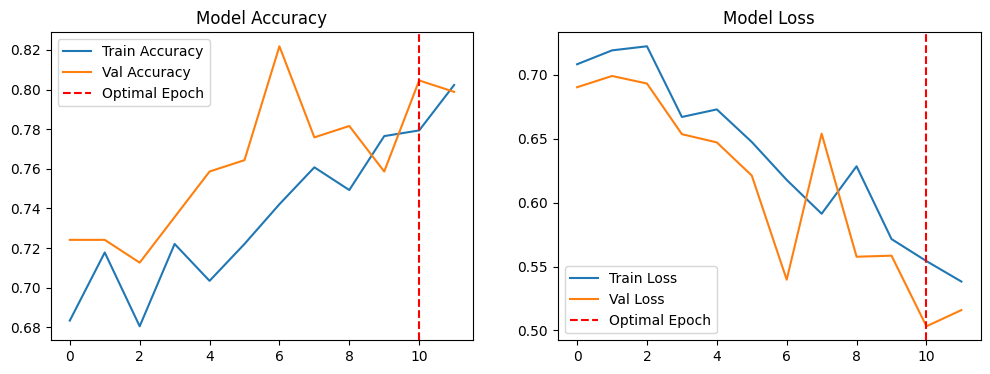

In [113]:
# Evaluate the model
results = model.evaluate(X_test, y_test)
print(f"Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}")

# Find the optimal epoch (min validation loss)
val_loss_per_epoch = hist.history['val_loss']
optimal_epoch = np.argmin(val_loss_per_epoch) + 1
print(f"\nOptimal Epoch (Minimum Validation Loss): {optimal_epoch}")

# Visualize training vs validation performance
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Val Accuracy')
plt.axvline(x=optimal_epoch-1, color='r', linestyle='--', label='Optimal Epoch')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Val Loss')
plt.axvline(x=optimal_epoch-1, color='r', linestyle='--', label='Optimal Epoch')
plt.title('Model Loss')
plt.legend()

plt.show()

In [1]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import io

# 1. Upload the image
print("Please upload an image file (jpg or png):")
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Load and preprocess the image
    img_path = filename
    # Load as grayscale and resize to 128x128
    img = image.load_img(img_path, target_size=(128, 128), color_mode="grayscale")

    # Convert to array and normalize
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # 3. Make prediction
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class] * 100

    # 4. Show result
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {labels[predicted_class]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"I am {confidence:.2f}% sure this is {labels[predicted_class]}.")

Please upload an image file (jpg or png):


Saving Screenshot 2026-04-10 210607.png to Screenshot 2026-04-10 210607.png


NameError: name 'np' is not defined

In [118]:
# Save the model in the native Keras format
model.save('football_model.keras')
print("Model saved as football_model.keras")

# Code to download the file directly to your computer
from google.colab import files
files.download('football_model.keras')

Model saved as football_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>